In [7]:
import torch
import pickle

from models.layers.embeddings import QuantileEmbeddingV2, CategoricalEmbedding
from models.tabmonet import TabMONet

FOLDER = "/Users/radiakbar/Documents/Projects/MONet_Tab/model_cache/863/base_tabmonet-2026-03-20 14:10:48.333235"

# Load the object from the file
with open(f'{FOLDER}/preprocessor.pkl', 'rb') as file:
    preprocessor = pickle.load(file)

weights = torch.load(
    f"{FOLDER}/tabmonet.pt",
    weights_only=True,
    map_location="cpu",
)
num_emb = QuantileEmbeddingV2(num_bins=64, bias=True, bin_edges=weights["numerical_encoder.bin_edges"])
model = TabMONet(
    num_features=6,
    num_blocks=1,
    feature_dim=64,
    n_estimator=4,
    n_classes=3,
    embed_dim=64,
    expansion_factor=3,
    numerical_encoder=num_emb,
    categorical_encoder=None
)
model.load_state_dict(weights)
model.eval()

TabMONet(
  (numerical_encoder): QuantileEmbeddingV2()
  (adapter): MultiLinearAdapter(
    (adapters): ModuleList(
      (0-3): 4 x Sequential(
        (0): Linear(in_features=384, out_features=64, bias=False)
      )
    )
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (poly_blocks): Sequential(
    (0): PolyBlock(
      (norm): LayerNorm((64,), eps=1e-06, elementwise_affine=True)
      (mlp1): PolyMLP(
        (norm1): LayerNorm((64,), eps=1e-06, elementwise_affine=True)
        (norm3): LayerNorm((64,), eps=1e-06, elementwise_affine=True)
        (U1): Linear(in_features=64, out_features=64, bias=False)
        (U2): Linear(in_features=64, out_features=8, bias=False)
        (U3): Linear(in_features=8, out_features=64, bias=False)
        (C): Linear(in_features=64, out_features=64, bias=True)
      )
      (mlp2): PolyMLP(
        (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
        (norm3): LayerNorm((192,), eps=1e-06, elementwise_affine=

In [8]:
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split

dataset = fetch_ucirepo(id=863)
X, X_test, y, y_test = train_test_split(
    dataset.data.features,
    dataset.data.targets,
    test_size=0.2
)
cat, cont, y_proc, _ = preprocessor.preprocess(
    X, y, is_train=False
)

cat_test, cont_test, y_proc_test, _ = preprocessor.preprocess(
    X_test, y_test, is_train=False
)

/Users/radiakbar/.pyenv/versions/tab_monet/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/Users/radiakbar/.pyenv/versions/tab_monet/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [9]:
from tabpfn import TabPFNClassifier

tabpfn = TabPFNClassifier()
tabpfn.fit(cont, y_proc)

,n_estimators,8
,categorical_features_indices,None
,softmax_temperature,0.9
,balance_probabilities,False
,average_before_softmax,False
,model_path,'auto'
,device,'auto'
,ignore_pretraining_limits,False
,inference_precision,'auto'
,fit_mode,'fit_preprocessors'
,memory_saving_mode,'auto'


In [10]:
with torch.no_grad():
    outputs = model(torch.tensor(cont_test), None).numpy()
    outputs2 = tabpfn.predict_logits(cont_test)

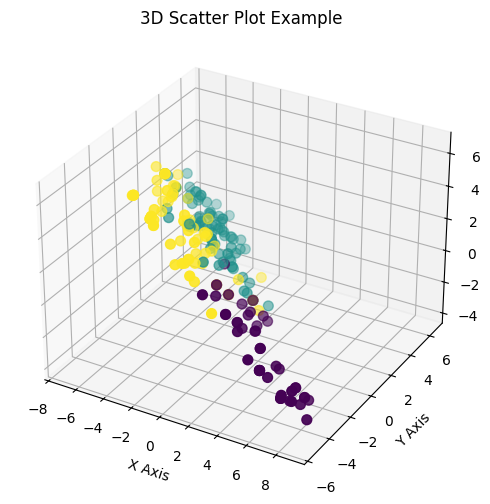

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Generate some random 3D data
np.random.seed(42)
x = outputs[:, 0]
y = outputs[:, 1]
z = outputs[:, 2]

# Create a 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D scatter
ax.scatter(x, y, z, c=y_proc_test, cmap='viridis', s=50)

# Set labels
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

# Set title
ax.set_title('3D Scatter Plot Example')

# Show the plot
plt.show()

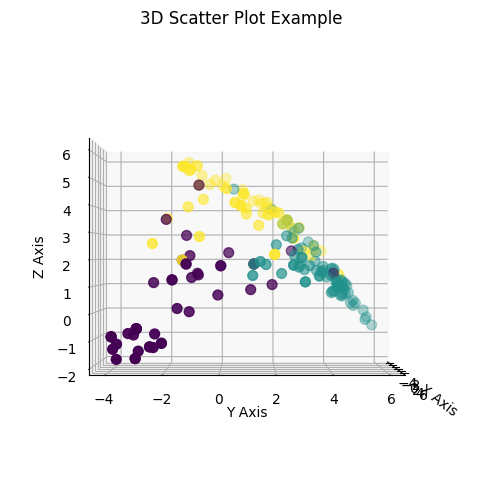

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Generate some random 3D data
np.random.seed(42)
x = outputs2[:, 0]
y = outputs2[:, 1]
z = outputs2[:, 2]

# Create a 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D scatter
ax.scatter(x, y, z, c=y_proc_test, cmap='viridis', s=50)

# Set labels
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

# Set title
ax.set_title('3D Scatter Plot Example')

# Show the plot
plt.show()